In [147]:
import pandas as pd
from scipy.stats import randint
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
x_train = pd.read_csv(r'C:\Projects_ciência_dados\students_performance\data\processed\x_train.csv')

In [87]:
x_train.columns

Index(['one_hot__gender_female', 'one_hot__gender_male',
       'one_hot__race/ethnicity_group A', 'one_hot__race/ethnicity_group B',
       'one_hot__race/ethnicity_group C', 'one_hot__race/ethnicity_group D',
       'one_hot__race/ethnicity_group E',
       'one_hot__parental level of education_associate's degree',
       'one_hot__parental level of education_bachelor's degree',
       'one_hot__parental level of education_high school',
       'one_hot__parental level of education_master's degree',
       'one_hot__parental level of education_some college',
       'one_hot__parental level of education_some high school',
       'one_hot__lunch_free/reduced', 'one_hot__lunch_standard',
       'one_hot__test preparation course_completed',
       'one_hot__test preparation course_none', 'scaler__math score'],
      dtype='object')

In [88]:
x_test = pd.read_csv(r'C:\Projects_ciência_dados\students_performance\data\processed\x_test.csv')

In [89]:
y_train = pd.read_csv(r'C:\Projects_ciência_dados\students_performance\data\processed\y_train.csv')

In [90]:
y_test = pd.read_csv(r'C:\Projects_ciência_dados\students_performance\data\processed\y_test.csv')

##### Arvore

In [109]:
parametros_arvore = {
    "max_depth": randint(10,20),
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,5,10],
    "criterion":["gini", "entropy"]
}

ra = RandomizedSearchCV(estimator=DecisionTreeClassifier(), param_distributions=parametros_arvore, n_jobs=4, verbose=True)
ra.fit(x_train,y_train)
melhores_parametros = ra.best_params_
melhor_resultado = ra.best_score_
print(melhores_parametros)
print(melhor_resultado)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'criterion': 'gini', 'max_depth': 14, 'min_samples_leaf': 5, 'min_samples_split': 5}
0.9024999999999999


##### Regressão logística

In [115]:
parametros_regression = {
    'C':[1.0,2.0,3.0,4.0],
    'penalty':['l1','l2','elasticnet'],
    'tol':[0.001, 0.0001, 0.00001],
    'fit_intercept':[True, False]
}

re = RandomizedSearchCV(estimator=LogisticRegression(), param_distributions=parametros_regression, n_jobs=4, verbose=True)
re.fit(x_train,y_train)
melhores_parametros = re.best_params_
melhor_resultado = re.best_score_
print(melhores_parametros)
print(melhor_resultado)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'tol': 0.001, 'penalty': 'l2', 'fit_intercept': True, 'C': 3.0}
0.9149999999999998


c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
40 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Projects_ciência_dados\s

In [132]:
parametros_random = {
    "n_estimators": randint(100,301), # no randint coloca o maior e menor
    "min_samples_split": randint(10,30),
    "min_samples_leaf": randint(10,30),
    "max_features": ['log2','sqrt'],
    "max_depth": randint(10,20)
}

random = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=parametros_random, n_jobs=4, verbose=True)
random.fit(x_train,y_train)
melhores_parametros = random.best_params_
melhor_resultado = random.best_score_
print(melhores_parametros)
print(melhor_resultado)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'max_depth': 11, 'max_features': 'log2', 'min_samples_leaf': 25, 'min_samples_split': 17, 'n_estimators': 157}
0.8975000000000002


c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [136]:
parametros_SVM = {
    "C":[1,2,4,5,6],
    "kernel":['poly','rbf','sigmoid','linear']
}

SVM = RandomizedSearchCV(estimator=SVC(), param_distributions=parametros_SVM, n_jobs=4)
SVM.fit(x_train,y_train)
melhores_parametros = SVM.best_params_
melhor_resultado = SVM.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'kernel': 'linear', 'C': 4}
0.91625


c:\Projects_ciência_dados\students_performance\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [140]:
parametros_xg = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}


xg = RandomizedSearchCV(estimator=XGBClassifier(), param_distributions=parametros_xg, n_jobs=4)
xg.fit(x_train,y_train)
melhores_parametros = xg.best_params_
melhor_resultado = xg.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.8}
0.90625


In [141]:
bernoulli_resultados = []
random_resultados = []
arvores_resultados = []
logistic_resultados = []
SVM_resultados = []
xgboost_resultados = []


for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)
    bernouli = BernoulliNB()
    scores = cross_val_score(bernouli, x_train, y_train, cv=kfold, n_jobs=4)
    bernoulli_resultados.append(scores.mean())
    
    random = RandomForestClassifier(max_depth = 11, max_features = 'log2', min_samples_leaf = 25, min_samples_split = 17, n_estimators = 157)
    scores = cross_val_score(random, x_train, y_train, cv=kfold, n_jobs=4)
    random_resultados.append(scores.mean())
    
    arvore = DecisionTreeClassifier(criterion = 'gini', max_depth = 14, min_samples_leaf = 5, min_samples_split = 5)
    scores = cross_val_score(arvore, x_train, y_train, cv=kfold, n_jobs=4)
    arvores_resultados.append(scores.mean())
    
    logistic = LogisticRegression(tol = 0.001, penalty = 'l2', fit_intercept = True, C = 3.0)
    scores = cross_val_score(logistic, x_train, y_train, cv=kfold, n_jobs=4)
    logistic_resultados.append(scores.mean())
    
    SVM = SVC(kernel = 'linear', C = 4)
    scores = cross_val_score(SVM, x_train, y_train, cv=kfold, n_jobs=4)
    SVM_resultados.append(scores.mean())
    
    xgb = XGBClassifier(subsample = 0.8, n_estimators = 200, min_child_weight = 5, max_depth = 9, learning_rate = 0.2, gamma = 0, colsample_bytree = 0.8)
    scores = cross_val_score(xgb, x_train, y_train, cv=kfold, n_jobs=4)
    xgboost_resultados.append(scores.mean())
    

In [150]:
resultados = pd.DataFrame({
    "random_forest":random_resultados,
    "arvore":arvores_resultados,
    "logistic":logistic_resultados,
    "SVM":SVM_resultados,
    "XGBoost":xgboost_resultados,
    "bernoulli":bernoulli_resultados
})

In [151]:
resultados

,random_forest,arvore,logistic,SVM,XGBoost,bernoulli
0,0.89000,0.88750,0.92000,0.90750,0.90000,0.84875
1,0.89375,0.89875,0.91750,0.91250,0.90500,0.84250
2,0.89000,0.89625,0.91250,0.91125,0.90000,0.84375
3,0.89750,0.89375,0.91625,0.91250,0.91250,0.84625
4,0.89500,0.89250,0.91125,0.90875,0.90625,0.84750
5,0.89250,0.89375,0.91500,0.91250,0.89750,0.84500
6,0.89375,0.89875,0.91750,0.91625,0.90000,0.84500
7,0.89000,0.89000,0.91250,0.91000,0.90625,0.84500
8,0.89125,0.88625,0.91875,0.91750,0.90250,0.84875
9,0.89500,0.88875,0.91125,0.91000,0.89375,0.84875


In [152]:
resultados.describe() # Logistc tem maior média e bernoulli tem o menor desvio padrão

,random_forest,arvore,logistic,SVM,XGBoost,bernoulli
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.892875,0.893000,0.915375,0.911417,0.901792,0.845458
std,0.003445,0.005682,0.003507,0.003768,0.004003,0.002355
min,0.883750,0.878750,0.907500,0.901250,0.893750,0.841250
25%,0.890000,0.890000,0.913750,0.909062,0.898750,0.843750
50%,0.893125,0.893750,0.915625,0.911250,0.902500,0.845000
75%,0.895000,0.896250,0.917500,0.913750,0.903750,0.847187
max,0.898750,0.905000,0.921250,0.917500,0.912500,0.850000


##### Coeficiente de variação

In [153]:
(resultados.std() / resultados.mean()) * 100

random_forest    0.385858
arvore           0.636276
logistic         0.383147
SVM              0.413387
XGBoost          0.443865
bernoulli        0.278591
dtype: float64

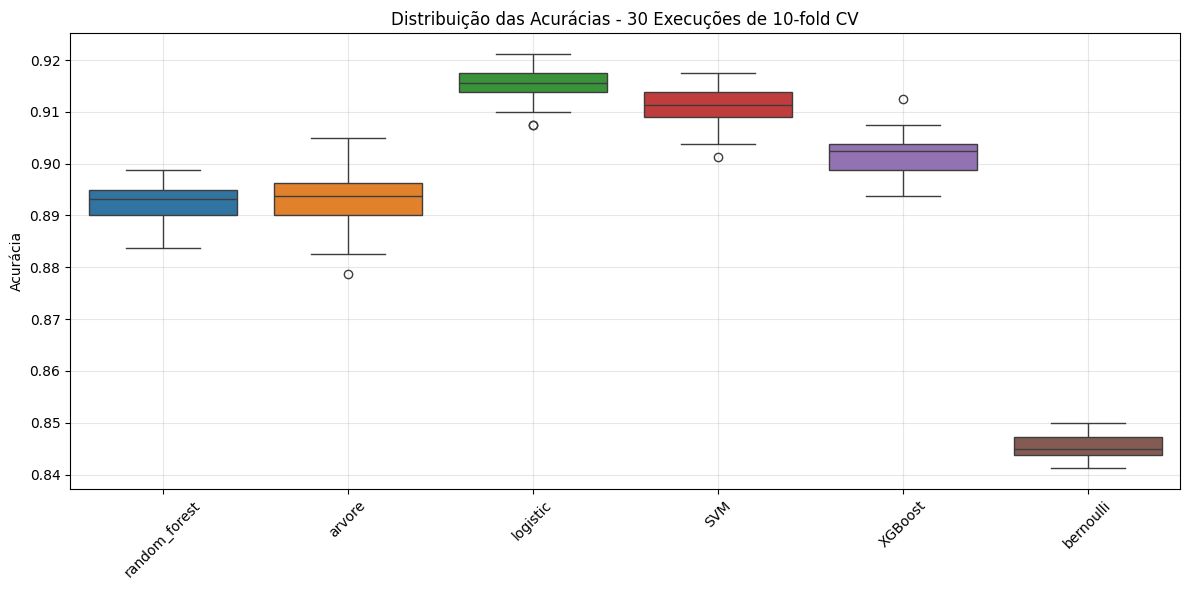

In [154]:
# Boxplot comparativo
plt.figure(figsize=(12, 6))
df_resultados = pd.DataFrame(resultados)
sns.boxplot(data=df_resultados)
plt.title('Distribuição das Acurácias - 30 Execuções de 10-fold CV')
plt.xticks(rotation=45)
plt.ylabel('Acurácia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Analisar quais resultados seguem uma distribuição normal

In [156]:
from scipy.stats import shapiro

In [158]:
alpha = 0.05

##### Todos apresentam distribuição normal, pois o pvalue é maior que 0.05

In [159]:
shapiro(random_resultados), shapiro(logistic_resultados), shapiro(arvores_resultados), shapiro(bernoulli_resultados), shapiro(SVM_resultados), shapiro(xgboost_resultados)

(ShapiroResult(statistic=np.float64(0.962411511968051), pvalue=np.float64(0.3564683604961639)),
 ShapiroResult(statistic=np.float64(0.9531551638708744), pvalue=np.float64(0.20522343433681095)),
 ShapiroResult(statistic=np.float64(0.9701544649312114), pvalue=np.float64(0.5434104048909397)),
 ShapiroResult(statistic=np.float64(0.944536332078535), pvalue=np.float64(0.12053464272731162)),
 ShapiroResult(statistic=np.float64(0.9575945416699283), pvalue=np.float64(0.2685387919714314)),
 ShapiroResult(statistic=np.float64(0.9733772824670255), pvalue=np.float64(0.6350685010604461)))

##### Gráficos de distribuição normal para confirmar

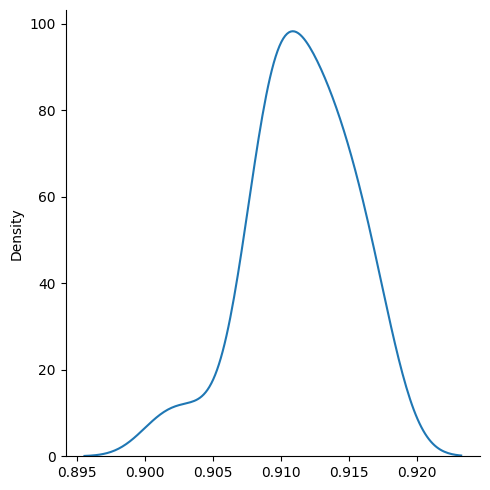

In [160]:
sns.displot(SVM_resultados, kind='kde')

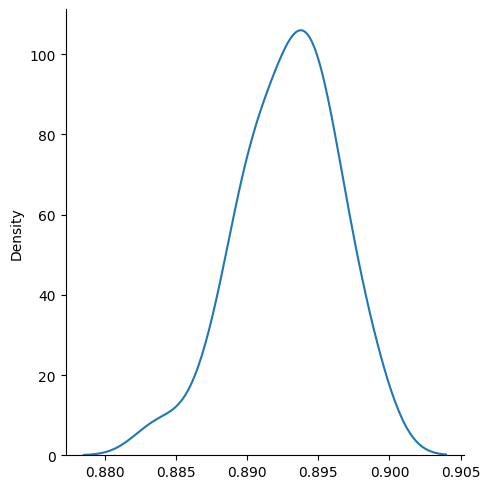

In [161]:
sns.displot(random_resultados, kind='kde')

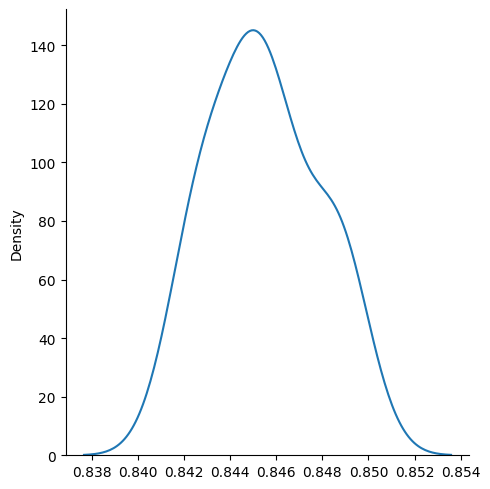

In [162]:
sns.displot(bernoulli_resultados, kind='kde')

##### Anova para verificar se os resultados são estatisticamente significativos

In [163]:
from scipy.stats import f_oneway

In [164]:
_, p = f_oneway(random_resultados, arvores_resultados, SVM_resultados, xgboost_resultados, bernoulli_resultados, logistic_resultados)

In [165]:
if p <= alpha:
    print("H0 rejeitada, existe diferença significativa entre os resultados")
else:
    print("H0 aceita, não existe diferença significativa entre os resultados")

H0 rejeitada, existe diferença significativa entre os resultados


In [166]:
p

np.float64(5.224365737453493e-134)